# Production Risk Scoring Dashboard
- Generate fraud probability scores
- Create risk tiers for business rules
- Visualize risk distribution
- Export scoring results

## Setup & Import 

In [5]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import joblib

SEED = 42
np.random.seed(SEED)

# Style settings
DARK = {
    "bg": "#0F1117", "panel": "#1A1D27", "grid": "#252836",
    "text": "#E8EAF0", "sub": "#8890A4", "blue": "#4F8EF7",
    "red": "#F7614F", "green": "#4FD1A5", "gold": "#F7C84F", "purple": "#A78BFA",
}

plt.rcParams.update({
    "figure.facecolor": DARK["bg"], "axes.facecolor": DARK["panel"],
    "axes.edgecolor": DARK["grid"], "axes.labelcolor": DARK["text"],
    "xtick.color": DARK["sub"], "ytick.color": DARK["sub"],
    "figure.dpi": 110,
})

## Load data and model

In [6]:
df = pd.read_csv("data/data_feature_engineered.csv")
FEATURES = np.load("data/features_list.npy", allow_pickle=True).tolist()
xgb_model = joblib.load("models/xgboost_model.pkl")
TARGET = "Is_Fraud"

print("Models and data loaded")

Models and data loaded


## Generate Risk Scores

In [7]:
X = df[FEATURES].values
y = df[TARGET].values

# Get predictions
fraud_proba = xgb_model.predict_proba(X)[:, 1]

# Create results dataframe
results_df = df.copy()
results_df["Fraud_Probability"] = fraud_proba

# Define risk tiers
results_df["Risk_Tier"] = pd.cut(
    results_df["Fraud_Probability"],
    bins=[0, 0.20, 0.50, 0.80, 1.0],
    labels=["Low", "Medium", "High", "Critical"]
)

print("Risk scoring complete")
print(f"\nRisk Tier Distribution:")
print(results_df["Risk_Tier"].value_counts())

Risk scoring complete

Risk Tier Distribution:
Risk_Tier
Low         199929
Medium          71
High             0
Critical         0
Name: count, dtype: int64


## Risk Dashboard Visualization

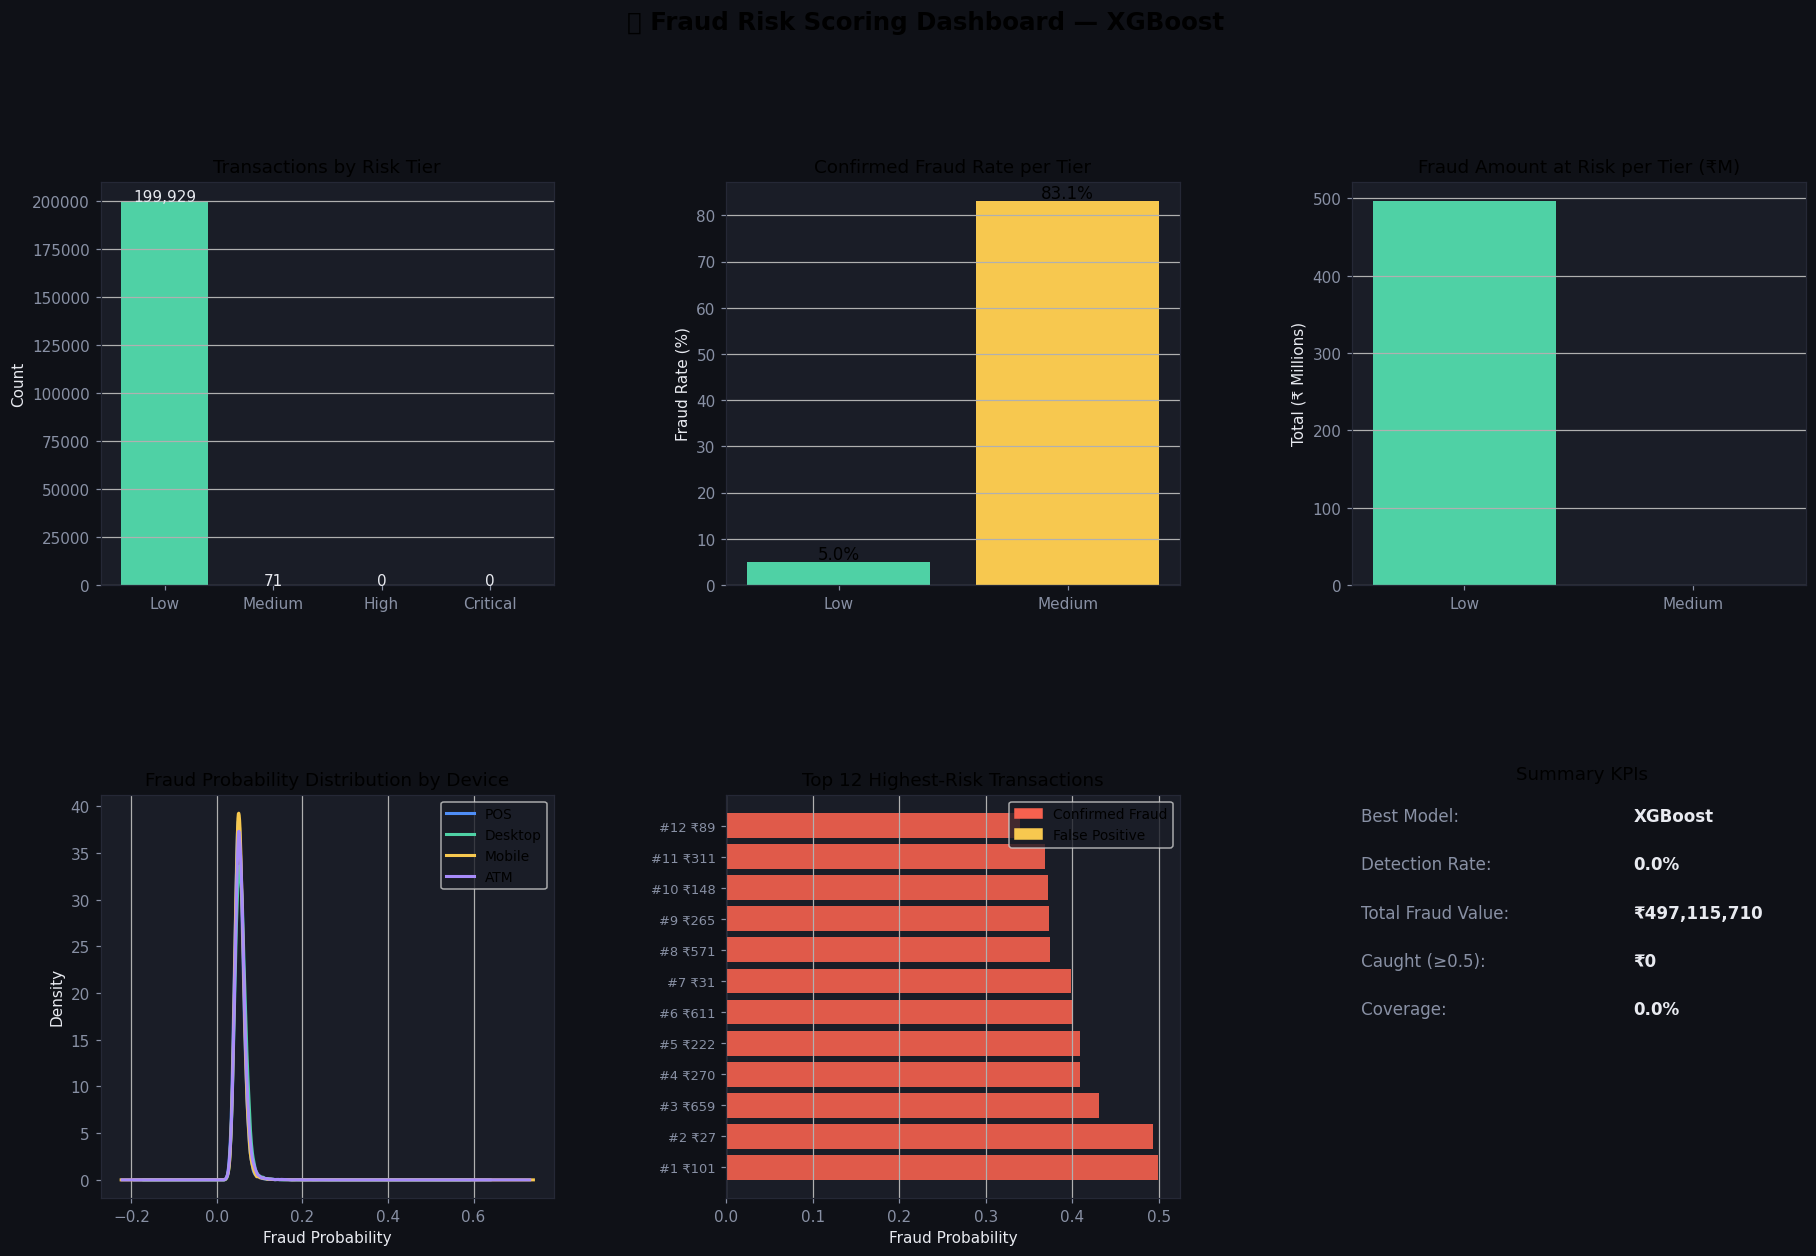

In [8]:
RISK_COLORS = {"Low": DARK["green"], "Medium": DARK["gold"], 
               "High": DARK["blue"], "Critical": DARK["red"]}

fig = plt.figure(figsize=(20, 12))
fig.suptitle("🚨 Fraud Risk Scoring Dashboard — XGBoost", fontsize=16, fontweight="bold", y=1.01)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.52, wspace=0.38)

# A) Transaction count by risk tier
axA = fig.add_subplot(gs[0, 0])
rl = results_df["Risk_Tier"].value_counts().reindex(["Low", "Medium", "High", "Critical"])
axA.bar(rl.index, rl.values, color=[RISK_COLORS[k] for k in rl.index], edgecolor="none")
for i, (k, v) in enumerate(rl.items()):
    axA.text(i, v + 30, f"{v:,}", ha="center", fontsize=10, color=DARK["text"])
axA.set_title("Transactions by Risk Tier")
axA.set_ylabel("Count")
axA.yaxis.grid(True)

# B) Actual fraud rate per tier
axB = fig.add_subplot(gs[0, 1])
fbr = results_df.groupby("Risk_Tier", observed=True)["Is_Fraud"].mean() * 100
bars = axB.bar(fbr.index, fbr.values, color=[RISK_COLORS[k] for k in fbr.index], edgecolor="none")
for bar, v in zip(bars, fbr.values):
    axB.text(bar.get_x() + bar.get_width()/2, v + 0.5, f"{v:.1f}%", ha="center", fontsize=11)
axB.set_title("Confirmed Fraud Rate per Tier")
axB.set_ylabel("Fraud Rate (%)")
axB.yaxis.grid(True)

# C) Fraud amount at risk
axC = fig.add_subplot(gs[0, 2])
amt = (results_df[results_df["Is_Fraud"] == 1]
       .groupby("Risk_Tier", observed=True)["Transaction_Amount"].sum() / 1e6)
axC.bar(amt.index, amt.values, color=[RISK_COLORS[k] for k in amt.index], edgecolor="none")
axC.set_title("Fraud Amount at Risk per Tier (₹M)")
axC.set_ylabel("Total (₹ Millions)")
axC.yaxis.grid(True)

# D) Probability distribution by device
axD = fig.add_subplot(gs[1, 0])
device_clrs = [DARK["blue"], DARK["green"], DARK["gold"], DARK["purple"]]
for i, dev in enumerate(results_df["Device_Type"].unique()[:4]):
    sub = results_df[results_df["Device_Type"] == dev]["Fraud_Probability"]
    sub.plot.kde(ax=axD, label=dev, color=device_clrs[i % 4], lw=2)
axD.set_title("Fraud Probability Distribution by Device")
axD.set_xlabel("Fraud Probability")
axD.legend(fontsize=9)
axD.xaxis.grid(True)

# E) Top 12 highest-risk transactions
axE = fig.add_subplot(gs[1, 1])
top12 = (results_df.nlargest(12, "Fraud_Probability")
         [["Fraud_Probability", "Transaction_Amount", "Is_Fraud"]].reset_index(drop=True))
clrs12 = [DARK["red"] if a else DARK["gold"] for a in top12["Is_Fraud"]]
axE.barh(np.arange(12), top12["Fraud_Probability"], color=clrs12, edgecolor="none", alpha=0.9)
axE.set_yticks(np.arange(12))
axE.set_yticklabels([f"#{i+1} ₹{a:,.0f}" for i, a in enumerate(top12["Transaction_Amount"])], fontsize=8.5)
axE.set_xlabel("Fraud Probability")
axE.set_title("Top 12 Highest-Risk Transactions")
p1 = mpatches.Patch(color=DARK["red"], label="Confirmed Fraud")
p2 = mpatches.Patch(color=DARK["gold"], label="False Positive")
axE.legend(handles=[p1, p2], fontsize=9)
axE.xaxis.grid(True)

# F) Summary KPIs
axF = fig.add_subplot(gs[1, 2])
axF.axis("off")
total_fraud_amt = results_df[results_df["Is_Fraud"] == 1]["Transaction_Amount"].sum()
caught_amt = results_df[(results_df["Is_Fraud"] == 1) & (results_df["Fraud_Probability"] >= 0.5)]["Transaction_Amount"].sum()

kpis = [
    ("Best Model", "XGBoost"),
    ("Detection Rate", f"{(results_df['Fraud_Probability'] >= 0.5).mean()*100:.1f}%"),
    ("Total Fraud Value", f"₹{total_fraud_amt:,.0f}"),
    ("Caught (≥0.5)", f"₹{caught_amt:,.0f}"),
    ("Coverage", f"{caught_amt/total_fraud_amt*100:.1f}%"),
]
y_pos = 0.97
for label, val in kpis:
    axF.text(0.02, y_pos, label+":", fontsize=11, color=DARK["sub"], transform=axF.transAxes, va="top")
    axF.text(0.62, y_pos, val, fontsize=11, color=DARK["text"], transform=axF.transAxes, va="top", fontweight="bold")
    y_pos -= 0.12
axF.set_title(" Summary KPIs", pad=10)

plt.tight_layout()
plt.show()

## Summary KPIs

In [9]:
axF = fig.add_subplot(gs[1, 2])
axF.axis("off")
total_fraud_amt = results_df[results_df["Is_Fraud"] == 1]["Transaction_Amount"].sum()
caught_amt = results_df[(results_df["Is_Fraud"] == 1) & (results_df["Fraud_Probability"] >= 0.5)]["Transaction_Amount"].sum()

kpis = [
    ("Best Model", "XGBoost"),
    ("Detection Rate", f"{(results_df['Fraud_Probability'] >= 0.5).mean()*100:.1f}%"),
    ("Total Fraud Value", f"₹{total_fraud_amt:,.0f}"),
    ("Caught (≥0.5)", f"₹{caught_amt:,.0f}"),
    ("Coverage", f"{caught_amt/total_fraud_amt*100:.1f}%"),
]
y_pos = 0.97
for label, val in kpis:
    axF.text(0.02, y_pos, label+":", fontsize=11, color=DARK["sub"], transform=axF.transAxes, va="top")
    axF.text(0.62, y_pos, val, fontsize=11, color=DARK["text"], transform=axF.transAxes, va="top", fontweight="bold")
    y_pos -= 0.12
axF.set_title("📊 Summary KPIs", pad=10)

plt.tight_layout()
plt.show()

<Figure size 704x528 with 0 Axes>

## Business Rules Summary

In [10]:
print("\n" + "="*60)
print("BUSINESS RULES RECOMMENDATIONS")
print("="*60)

rules = {
    "Low (0-0.20)": {"count": rl["Low"], "action": "🟢 Auto-approve"},
    "Medium (0.20-0.50)": {"count": rl["Medium"], "action": "🟡 Log & monitor"},
    "High (0.50-0.80)": {"count": rl["High"], "action": "🟠 Secondary review required"},
    "Critical (0.80-1.00)": {"count": rl["Critical"], "action": "🔴 Block transaction & alert"}
}

for tier, info in rules.items():
    print(f"\n{tier}: {info['count']:,} transactions")
    print(f"  → {info['action']}")


BUSINESS RULES RECOMMENDATIONS

Low (0-0.20): 199,929 transactions
  → 🟢 Auto-approve

Medium (0.20-0.50): 71 transactions
  → 🟡 Log & monitor

High (0.50-0.80): 0 transactions
  → 🟠 Secondary review required

Critical (0.80-1.00): 0 transactions
  → 🔴 Block transaction & alert
